<a href="https://colab.research.google.com/github/MishelleMol/INTRO_A_DATOS/blob/main/Casodeestudio1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Reporte Escrito — Análisis del Sistema de Puntos GNC Rewards

Mishelle Molina-20250239

Danilo Cerna

### 1. Resumen de la situación

GNC (General Nutrition Centers) es una cadena internacional de suplementos nutricionales con presencia en Guatemala. Su programa de lealtad GNC Rewards permite a los clientes acumular puntos con cada compra y canjearlos por descuentos en compras futuras.



Como equipo de consultores, fuimos contratados para analizar y documentar el sistema, dado que los responsables originales de su diseño e implementación ya no trabajan en la empresa. Se cuenta con una semana para realizar el diagnóstico y propuestas de optimización.

¿Cómo funciona el sistema?



*   Membresía Member-Gratis(Q1=1 punto)
*   Membresía Pro Access-Q310(Q1=2 puntos)
*   Canje (100 puntos=Q1 de descuento)
*   Canales (App móvil, tienda física, sitio web, tarjeta GNC)
*   Niveles (Member y Pro Access)








### 2. Análisis del Sistema

2.1 Arquitectura de Datos

El sistema se organiza en 5 capas que forman un pipeline completo de datos:

Capa 1-Fuentes de Datos: Los datos ingresan al sistema desde cuatro fuentes principales: la App Móvil de GNC, el sitio web GNC.com, los terminales POS ubicados en tiendas físicas en Guatemala, y la Tarjeta GNC/Membresía Pro. Cada fuente genera eventos de transacción cada vez que un cliente realiza una compra.

Capa 2 — Ingesta de Datos: Los eventos generados por las fuentes son recibidos mediante una API REST y procesados a través de una Cola de Mensajes. Esto garantiza que ninguna transacción se pierda incluso cuando múltiples clientes compran simultáneamente.

Capa 3 — Almacenamiento: Los datos se almacenan en cuatro bases de datos separadas: BD Clientes (información personal y tipo de membresía), BD Transacciones (historial de compras), BD Puntos (saldo y movimientos de puntos), y BD Productos (catálogo con precios en quetzales).

Capa 4 — Procesamiento: Esta capa aplica las reglas de negocio del programa: cálculo de puntos según membresía, asignación de niveles, motor de recompensas y envío de notificaciones al cliente.

Capa 5 — Consumo: Los datos procesados son utilizados por tres tipos de usuarios: el cliente final (consulta su saldo desde la app), el equipo de marketing (campañas personalizadas) y la gerencia (reportes de rendimiento del programa)

2.2 Problemas Identificados

Durante el diagnóstico se encontraron los siguientes problemas:

a) Falta de documentación: Al no haber documentación del sistema original, cualquier cambio o corrección requiere análisis desde cero, lo que aumenta el riesgo de errores.

b) Inconsistencias entre canales: Los puntos acumulados en tienda física no siempre se sincronizan correctamente con los registrados en la app, generando reclamos de clientes.

c) Sin métricas de rendimiento: El sistema no cuenta con KPIs definidos para evaluar si el programa de lealtad está generando retorno de inversión.

d) Datos dispersos: Las cuatro bases de datos no están integradas en un repositorio centralizado, lo que dificulta el análisis cruzado.

### 3. Prueba de Concepto (POC)

Se desarrolló una réplica en miniatura del sistema en Python (ver Notebook adjunto) que demuestra el funcionamiento del pipeline completo:

Extracción: Simulación de eventos de transacción provenientes de las 4 fuentes

Limpieza: Eliminación de registros nulos, errores y duplicados

Filtrado: Solo se procesan transacciones completadas mayores a Q50

Cálculo de puntos: Aplicación de multiplicadores según membresía (Member x1, Pro Access x2)

Visualización: Dashboard con KPIs en quetzales y distribución por canal y membresía

### 4. Diagrama con la Arquitectura de Datos del Sistema

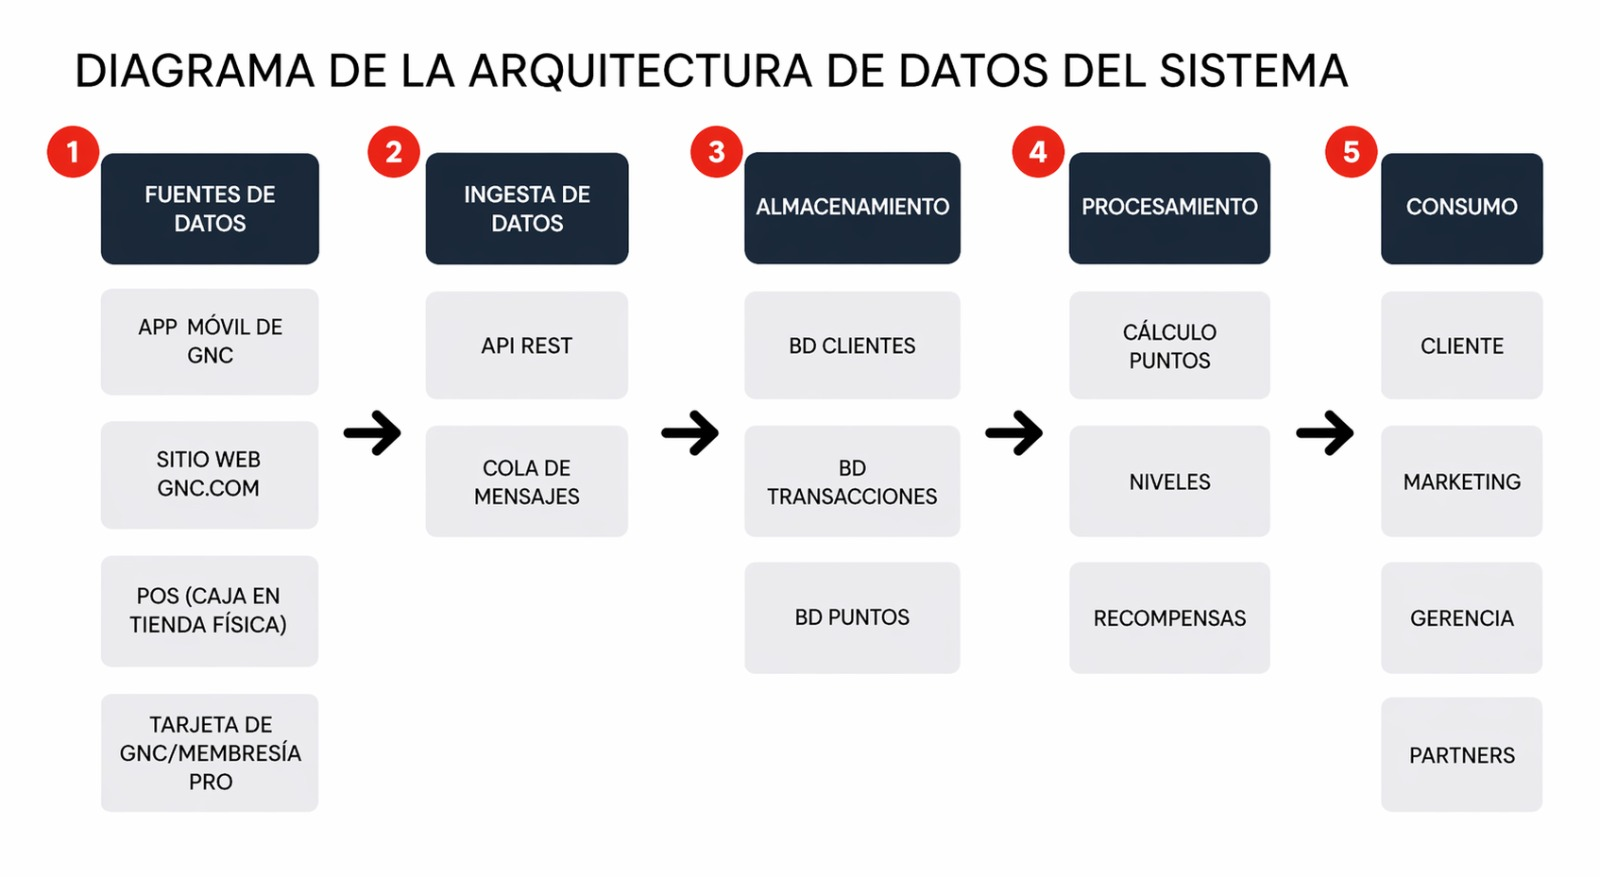

### 5.Conclusiones

1. El canal digital es el más utilizado: La App Móvil concentra el mayor volumen de transacciones (~40%), lo que indica que los clientes guatemaltecos prefieren la comodidad digital.

2. Pro Access genera mayor valor: El doble multiplicador incentiva compras más grandes, pero su adopción es baja (~35-40%). Existe una oportunidad clara de convertir más clientes Member a Pro Access mediante promociones.

3. El pasivo en puntos es un riesgo financiero: Los puntos acumulados sin canjear representan un compromiso económico futuro que debe monitorearse constantemente.

4. Se requiere integración de datos: La principal propuesta de optimización es unificar las cuatro bases de datos en un Data Warehouse centralizado para eliminar inconsistencias entre canales y facilitar el análisis.

5. Se necesitan KPIs formales: El programa debe medir indicadores como tasa de retención, tasa de canje, ROI del programa y ticket promedio por tipo de membresía.

## RÉPLICA EN MINIATURA-ARQUITECTURA DE DATOS GNC REWARDS

Este notebook replica en miniatura las 5 capas de la arquitectura de datos del sistema GNC Rewards:

| # | Capa | Descripción |
|---|---|---|
| 1 | **Fuentes de Datos** | App, Web, POS, Tarjeta GNC |
| 2 | **Ingesta** | Simulación de API REST y Cola de Mensajes |
| 3 | **Almacenamiento** | BD Clientes, Transacciones, Puntos, Productos |
| 4 | **Procesamiento** | Limpieza, Filtrado, Cálculo de Puntos |
| 5 | **Consumo** | Reportes y visualizaciones finales |

### LIBRERÍAS

In [ ]:
import pandas as pd # Importa la librería pandas y le da el alias "pd"
# Sirve para trabajar con datos en forma de tablas (DataFrames), como si fueran hojas de Excel

import numpy as np# Se usa para operaciones matemáticas y manejo de arreglos (vectores, matrices)

import matplotlib.pyplot as plt #Sirve para crear gráficos (líneas, barras, etc.)

from datetime import datetime, timedelta
# Importa dos herramientas del módulo datetime:
# - datetime: para trabajar con fechas y horas exactas
# - timedelta: para hacer operaciones con fechas (sumar/restar días, horas, etc.)


import random# Permite generar números aleatorios (muy útil para simulaciones o pruebas)

import warnings
warnings.filterwarnings('ignore')# Indica que ignore todas las advertencias (warnings)


print("Librerías cargadas")# Imprime un mensaje en consola indicando que todas las librerías se importaron correctamente

Librerías cargadas


### CAPA 1-FUENTES DE DATOS

In [ ]:
random.seed(42)
# Fija la semilla del generador de números aleatorios de la librería random
# Sirve para que los resultados sean siempre los mismos cada vez que ejecutas el código (reproducibilidad)

np.random.seed(42)
# Hace lo mismo pero para numpy
# Garantiza que los números aleatorios generados con numpy sean consistentes en cada ejecución

# Simulación de eventos crudos provenientes de cada fuente
fuentes = ['App Móvil', 'Sitio Web GNC.com', 'POS Tienda Física', 'Tarjeta GNC/Membresía Pro']
# Lista con las diferentes fuentes de donde pueden venir los datos (canales de venta/interacción)

eventos_crudos = pd.DataFrame({
# Se crea un DataFrame (tabla) con pandas que contiene todos los eventos simulados

    'evento_id':    [f'EVT{str(i).zfill(4)}' for i in range(1, 21)],
     # Genera IDs únicos para cada evento (EVT0001, EVT0002, ..., EVT0020)
     # zfill(4) asegura que todos tengan 4 dígitos con ceros a la izquierda

    'fuente':       random.choices(fuentes, weights=[0.4, 0.25, 0.25, 0.1], k=20),
       # Selecciona aleatoriamente la fuente de cada evento
       # weights define la probabilidad (App Móvil es más frecuente)
       # k=20 indica que se generan 20 valores


    'cliente_id':   random.choices([f'GNC{str(i).zfill(3)}' for i in range(1, 11)], k=20),
       # Genera IDs de clientes (GNC001 a GNC010)
       # Se asignan aleatoriamente a cada evento

    'timestamp':    [datetime(2025, 1, 1) + timedelta(days=random.randint(0, 365),
                     hours=random.randint(0, 23)) for _ in range(20)],
       # Genera fechas y horas aleatorias para cada evento
       # Parte desde 1 de enero de 2025
       # Suma días (0 a 365) y horas (0 a 23) aleatoriamente

    'monto_gtq':    np.round(np.random.uniform(50, 1200, 20), 2),
       # Genera montos de compra aleatorios entre Q50 y Q1200
       # np.round(..., 2) redondea a 2 decimales (como dinero real)

    'producto':     random.choices(['Proteína Whey', 'Vitamina C', 'Pre-entreno',
                                    'Quemador', 'Aminoácidos'], k=20),
       # Asigna un producto aleatorio a cada evento


    'estado':       random.choices(['OK', 'OK', 'OK', 'ERROR', None],
                                    weights=[0.7, 0.1, 0.1, 0.05, 0.05], k=20),
       # Estado del evento:
       # - Mayoría "OK"
       # - Algunos "ERROR"
       # - Algunos valores nulos (None) para simular datos incompletos


})

print("CAPA 1 — Eventos crudos recibidos de las fuentes:") # Imprime un título para indicar qué se está mostrando
print(f"Total de eventos: {len(eventos_crudos)}")# Muestra cuántos eventos hay en total (en este caso 20)
eventos_crudos.head(8)

# Muestra las primeras 8 filas del DataFrame
# Sirve para visualizar rápidamente cómo se ven los datos

CAPA 1 — Eventos crudos recibidos de las fuentes:
Total de eventos: 20


,evento_id,fuente,cliente_id,timestamp,monto_gtq,producto,estado
0,EVT0001,Sitio Web GNC.com,GNC009,2025-12-27 02:00:00,480.72,Vitamina C,None
1,EVT0002,App Móvil,GNC007,2025-01-24 21:00:00,1143.32,Proteína Whey,OK
2,EVT0003,App Móvil,GNC004,2025-04-27 09:00:00,891.79,Vitamina C,OK
3,EVT0004,App Móvil,GNC002,2025-02-10 07:00:00,738.46,Vitamina C,OK
4,EVT0005,POS Tienda Física,GNC010,2025-02-21 12:00:00,229.42,Vitamina C,OK
5,EVT0006,POS Tienda Física,GNC004,2025-05-23 14:00:00,229.39,Aminoácidos,OK
6,EVT0007,POS Tienda Física,GNC001,2025-11-22 11:00:00,116.80,Aminoácidos,OK
7,EVT0008,App Móvil,GNC001,2025-03-25 11:00:00,1046.10,Vitamina C,OK


### CAPA 2-INGESTA DE DATOS

Simulamos cómo los datos pasan por la **API REST** y la **Cola de Mensajes** antes de almacenarse.

La cola asegura que ningún evento se pierda aunque lleguen muchos al mismo tiempo.

In [ ]:
# Simulación de la Cola de Mensajes
# En un sistema real: RabbitMQ, Kafka, AWS SQS, etc.

cola_de_mensajes = []
# Se crea una lista vacía llamada "cola_de_mensajes"
# Representa una cola (queue) donde se almacenarán los eventos procesados como mensajes


for _, evento in eventos_crudos.iterrows(): # Recorre cada fila del DataFrame "eventos_crudos"
    mensaje = {
        'evento_id': evento['evento_id'], #Se extrae el ID del evento
        'fuente': evento['fuente'],# Se extrae la fuente del evento (App, Web, POS, etc.)
        'cliente_id': evento['cliente_id'],# Se extrae el ID del cliente
        'timestamp': evento['timestamp'],# Se extrae la fecha y hora del evento original
        'monto_gtq': evento['monto_gtq'],# Se extrae el monto de la transacción en quetzales
        'producto': evento['producto'],# Se extrae el producto comprado
        'estado': evento['estado'],# Se extrae el estado del evento (OK, ERROR o None)
        'recibido_en_cola': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
         # Se agrega la fecha y hora actual en la que el mensaje entra a la cola


    }
    cola_de_mensajes.append(mensaje)# Agrega el mensaje (diccionario) a la lista "cola_de_mensajes"

df_cola = pd.DataFrame(cola_de_mensajes)
# Convierte la lista de mensajes en un DataFrame (tabla)
# Esto permite analizar y visualizar fácilmente los datos



print("CAPA 2 — Cola de Mensajes (API REST → Cola):")# Imprime un título indicando la etapa del proceso (pipeline de datos)


print(f"Mensajes en cola: {len(df_cola)}")# Muestra cuántos mensajes hay en la cola
print(f"Fuentes detectadas: {df_cola['fuente'].unique()}")# Muestra las diferentes fuentes presentes en los datos (sin repetir)
df_cola[['evento_id', 'fuente', 'cliente_id', 'monto_gtq', 'estado']].head(5)
# Muestra las primeras 5 filas del DataFrame
# Solo se seleccionan ciertas columnas para visualizar mejor la información clave


CAPA 2 — Cola de Mensajes (API REST → Cola):
Mensajes en cola: 20
Fuentes detectadas: ['Sitio Web GNC.com' 'App Móvil' 'POS Tienda Física']


,evento_id,fuente,cliente_id,monto_gtq,estado
0,EVT0001,Sitio Web GNC.com,GNC009,480.72,None
1,EVT0002,App Móvil,GNC007,1143.32,OK
2,EVT0003,App Móvil,GNC004,891.79,OK
3,EVT0004,App Móvil,GNC002,738.46,OK
4,EVT0005,POS Tienda Física,GNC010,229.42,OK


### CAPA 3-ALMACENAMIENTO

Los datos se distribuyen en 4 bases de datos: **Clientes, Transacciones, Puntos y Productos**.

In [ ]:
# ---- BD CLIENTES ----
bd_clientes = pd.DataFrame({ # Se crea un DataFrame llamado "bd_clientes" (tabla de clientes)


    'cliente_id':  [f'GNC{str(i).zfill(3)}' for i in range(1, 11)],
                   # Genera IDs de clientes desde GNC001 hasta GNC010
                   # zfill(3) asegura que tengan 3 dígitos con ceros a la izquierda

    'nombre':      ['Danilo Cerna', 'Dhidel Osorio', 'Mishelle Molina', 'Luis Montenegro', 'Sofia Bilbao',
                    'Miguel Cuevas', 'Daniel Piñol', 'Alex ', 'Jimena García', 'Diego Escobedo'],
                   # Lista con los nombres de los clientes


    'email':       [f'cliente{i}@gmail.com' for i in range(1, 11)],
                   # Genera correos electrónicos automáticamente (cliente1@gmail.com, etc.)

    'membresia':   random.choices(['Member', 'Pro Access'], weights=[0.6, 0.4], k=10),
                   # Asigna tipo de membresía aleatoriamente a cada cliente
                   # 60% probabilidad de "Member" y 40% de "Pro Access"

    'ciudad':      random.choices(['Guatemala', 'Quetzaltenango', 'Escuintla', 'Antigua'], k=10),
})                 # Asigna una ciudad aleatoria a cada cliente

# ---- BD PRODUCTOS ----
bd_productos = pd.DataFrame({
    # Se crea un DataFrame llamado "bd_productos" (tabla de productos)


    'producto':    ['Proteína Whey', 'Vitamina C', 'Pre-entreno', 'Quemador', 'Aminoácidos'],# Lista de nombres de productos
    'categoria':   ['Proteínas', 'Vitaminas', 'Pre-entreno', 'Quemadores', 'Aminoácidos'],# Categoría a la que pertenece cada producto
    'precio_gtq':  [459.99, 89.99, 279.99, 349.99, 199.99],# Precio de cada producto en quetzales (GTQ)
})

print("CAPA 3 — Bases de Datos:")# Imprime un título indicando la etapa del pipeline (bases de datos)
print("\nBD Clientes:")# Imprime subtítulo para la base de datos de clientes
print(bd_clientes.to_string(index=False))# Muestra toda la tabla de clientes en formato texto
print("\nBD Productos:")# Imprime subtítulo para la base de datos de productos
print(bd_productos.to_string(index=False))

CAPA 3 — Bases de Datos:

BD Clientes:
cliente_id          nombre               email  membresia         ciudad
    GNC001    Danilo Cerna  cliente1@gmail.com     Member      Guatemala
    GNC002   Dhidel Osorio  cliente2@gmail.com Pro Access        Antigua
    GNC003 Mishelle Molina  cliente3@gmail.com Pro Access        Antigua
    GNC004 Luis Montenegro  cliente4@gmail.com Pro Access      Guatemala
    GNC005    Sofia Bilbao  cliente5@gmail.com     Member Quetzaltenango
    GNC006           Diego  cliente6@gmail.com     Member      Escuintla
    GNC007    Daniel Piñol  cliente7@gmail.com Pro Access Quetzaltenango
    GNC008           Alex   cliente8@gmail.com Pro Access        Antigua
    GNC009   Jimena García  cliente9@gmail.com     Member Quetzaltenango
    GNC010      Pedro Batz cliente10@gmail.com     Member      Guatemala

BD Productos:
     producto   categoria  precio_gtq
Proteína Whey   Proteínas      459.99
   Vitamina C   Vitaminas       89.99
  Pre-entreno Pre-entreno    

### CAPA 4-PROCESAMIENTO

4.1 EXTRACCIÓN: Tomamos los datos de la cola y los preparamos para procesar.

In [ ]:
df = df_cola.copy()
# Se crea una copia del DataFrame "df_cola" y se guarda en "df"
# copy() evita modificar el original, lo cual es buena práctica en procesos de datos

print("EXTRACCIÓN — Datos tomados de la cola:")# Imprime un título indicando la etapa del proceso: extracción (ETL)
print(f"Registros extraídos: {len(df)}")# Muestra la cantidad total de filas (registros) en el DataFrame
print(f"Columnas: {list(df.columns)}")# Muestra una lista con los nombres de todas las columnas del DataFrame
print(f"\nValores nulos por columna:")# Imprime un subtítulo indicando que se analizarán los datos faltantes
print(df.isnull().sum())
# isnull() identifica valores nulos (NaN o None)
# sum() cuenta cuántos hay por cada columna


EXTRACCIÓN — Datos tomados de la cola:
Registros extraídos: 20
Columnas: ['evento_id', 'fuente', 'cliente_id', 'timestamp', 'monto_gtq', 'producto', 'estado', 'recibido_en_cola']

Valores nulos por columna:
evento_id           0
fuente              0
cliente_id          0
timestamp           0
monto_gtq           0
producto            0
estado              3
recibido_en_cola    0
dtype: int64


4.2 LIMPIEZA

In [ ]:
print(f"Registros antes de limpieza: {len(df)}")
# Muestra la cantidad de registros antes de aplicar cualquier limpieza de datos

# Paso 1: Eliminar filas con valores nulos
df = df.dropna(subset=['estado', 'monto_gtq', 'cliente_id'])
# Elimina filas que tengan valores nulos en las columnas clave:
# - 'estado'
# - 'monto_gtq'
# - 'cliente_id'
# Esto asegura que los datos esenciales estén completos


# Paso 2: Eliminar eventos con ERROR
df = df[df['estado'] == 'OK']
# Filtra el DataFrame y solo deja los registros donde el estado sea "OK"
# Se eliminan eventos fallidos o incorrectos


# Paso 3: Eliminar montos inválidos
df = df[df['monto_gtq'] > 0]
# Filtra y deja solo los registros con montos mayores a 0
# Evita datos incorrectos como montos negativos o cero


# Paso 4: Eliminar duplicados
df = df.drop_duplicates(subset='evento_id')
# Elimina filas duplicadas basándose en el 'evento_id'
# Garantiza que cada evento sea único




print(f"Registros después de limpieza: {len(df)}")# Muestra cuántos registros quedaron después de limpiar los datos

print(f"Registros eliminados: {len(df_cola) - len(df)}")# Calcula cuántos registros fueron eliminados durante la limpieza

print("\nDatos limpios:")# Imprime un subtítulo para mostrar los datos finales

df[['evento_id', 'fuente', 'cliente_id', 'monto_gtq', 'producto']].head(8)# Muestra las primeras 8 filas de los datos ya limpios

Registros antes de limpieza: 20
Registros después de limpieza: 17
Registros eliminados: 3

Datos limpios:


,evento_id,fuente,cliente_id,monto_gtq,producto
1,EVT0002,App Móvil,GNC007,1143.32,Proteína Whey
2,EVT0003,App Móvil,GNC004,891.79,Vitamina C
3,EVT0004,App Móvil,GNC002,738.46,Vitamina C
4,EVT0005,POS Tienda Física,GNC010,229.42,Vitamina C
5,EVT0006,POS Tienda Física,GNC004,229.39,Aminoácidos
6,EVT0007,POS Tienda Física,GNC001,116.80,Aminoácidos
7,EVT0008,App Móvil,GNC001,1046.10,Vitamina C
8,EVT0009,Sitio Web GNC.com,GNC009,741.28,Quemador


4.3 FILTRADO

In [ ]:
# Unir con BD Clientes para obtener membresía
df = df.merge(bd_clientes[['cliente_id', 'nombre', 'membresia', 'ciudad']],
              on='cliente_id', how='left')
# Se hace un JOIN entre el DataFrame "df" y la tabla "bd_clientes"
# Solo se traen las columnas necesarias: cliente_id, nombre, membresia y ciudad
# on='cliente_id' indica la columna clave para unir ambas tablas
# how='left' significa:
# - Se conservan todos los registros de "df"
# - Se agregan los datos de clientes cuando coinciden
# (equivalente a un LEFT JOIN en SQL)



# Filtro 1: Solo clientes registrados
df = df.dropna(subset=['membresia'])
# Elimina registros donde "membresia" sea nula
# Esto asegura que solo se consideren clientes que existen en la BD de clientes



# Filtro 2: Solo transacciones mayores a Q50
df = df[df['monto_gtq'] >= 50]
# Filtra y deja solo las transacciones con monto mayor o igual a Q50
# Sirve para evitar compras muy pequeñas o no relevantes

print("FILTRADO — Datos listos para calcular puntos:")# Imprime un título indicando que los datos ya están filtrados
print(f"Registros válidos: {len(df)}")# Muestra la cantidad de registros que cumplen con los filtros
df[['cliente_id', 'nombre', 'membresia', 'monto_gtq', 'producto', 'fuente']].head(8)
# Muestra las primeras 8 filas con información clave:
# cliente, nombre, tipo de membresía, monto, producto y fuente
# Sirve para validar visualmente que el filtrado fue correcto

FILTRADO — Datos listos para calcular puntos:
Registros válidos: 17


,cliente_id,nombre,membresia,monto_gtq,producto,fuente
0,GNC007,Daniel Piñol,Pro Access,1143.32,Proteína Whey,App Móvil
1,GNC004,Luis Montenegro,Pro Access,891.79,Vitamina C,App Móvil
2,GNC002,Dhidel Osorio,Pro Access,738.46,Vitamina C,App Móvil
3,GNC010,Pedro Batz,Member,229.42,Vitamina C,POS Tienda Física
4,GNC004,Luis Montenegro,Pro Access,229.39,Aminoácidos,POS Tienda Física
5,GNC001,Danilo Cerna,Member,116.80,Aminoácidos,POS Tienda Física
6,GNC001,Danilo Cerna,Member,1046.10,Vitamina C,App Móvil
7,GNC009,Jimena García,Member,741.28,Quemador,Sitio Web GNC.com


4.4 CÁLCULO DE PUNTOS-MOTOR DE RECOMPENSAS

In [ ]:
# Reglas de negocio GNC Guatemala
# Member:     Q1 gastado = 1 punto
# Pro Access: Q1 gastado = 2 puntos
# 100 puntos = Q1 de descuento

multiplicadores = {'Member': 1, 'Pro Access': 2}
# Se crea un diccionario que define cuántos puntos gana cada tipo de membresía
# - Member: gana 1 punto por cada quetzal
# - Pro Access: gana 2 puntos por cada quetzal (beneficio mayor)


df['multiplicador'] = df['membresia'].map(multiplicadores)
# Se crea una nueva columna "multiplicador"
# map() asigna el valor correspondiente según la membresía del cliente
# Ejemplo: si es "Pro Access" → multiplicador = 2


df['puntos_ganados'] = (df['monto_gtq'] * df['multiplicador']).astype(int)
# Se calcula la cantidad de puntos ganados por cada transacción
# Fórmula: monto_gtq * multiplicador
# astype(int) convierte el resultado a número entero (sin decimales)

df['descuento_disponible_gtq'] = (df['puntos_ganados'] / 100).round(2)
# Convierte los puntos en dinero disponible para descuento
# Ejemplo: 100 puntos = Q1 de descuento
# round(2) redondea a 2 decimales (formato de dinero)


print("CÁLCULO DE PUNTOS:")# Imprime un título para esta etapa del proceso
print(df[['nombre', 'membresia', 'monto_gtq', 'multiplicador',
          'puntos_ganados', 'descuento_disponible_gtq']].to_string(index=False))


CÁLCULO DE PUNTOS:
         nombre  membresia  monto_gtq  multiplicador  puntos_ganados  descuento_disponible_gtq
   Daniel Piñol Pro Access    1143.32              2            2286                     22.86
Luis Montenegro Pro Access     891.79              2            1783                     17.83
  Dhidel Osorio Pro Access     738.46              2            1476                     14.76
     Pedro Batz     Member     229.42              1             229                      2.29
Luis Montenegro Pro Access     229.39              2             458                      4.58
   Danilo Cerna     Member     116.80              1             116                      1.16
   Danilo Cerna     Member    1046.10              1            1046                     10.46
  Jimena García     Member     741.28              1             741                      7.41
   Daniel Piñol Pro Access     864.28              2            1728                     17.28
          Alex  Pro Access    1

CAPA 5-CONSUMO

In [ ]:
print("="*50)
print("     KPIs — GNC REWARDS GUATEMALA")
print("="*50)
print(f"  Ingresos Totales:      Q{df['monto_gtq'].sum():>10,.2f}")
print(f"  Ticket Promedio:       Q{df['monto_gtq'].mean():>10,.2f}")
print(f"  Clientes Únicos:       {df['cliente_id'].nunique():>11}")
print(f"  Puntos Emitidos:       {df['puntos_ganados'].sum():>11,}")
print(f"  Pasivo (Q):            Q{(df['puntos_ganados'].sum()/100):>10,.2f}")
print("="*50)

     KPIs — GNC REWARDS GUATEMALA
  Ingresos Totales:      Q  9,965.45
  Ticket Promedio:       Q    586.20
  Clientes Únicos:                 8
  Puntos Emitidos:            15,900
  Pasivo (Q):            Q    159.00


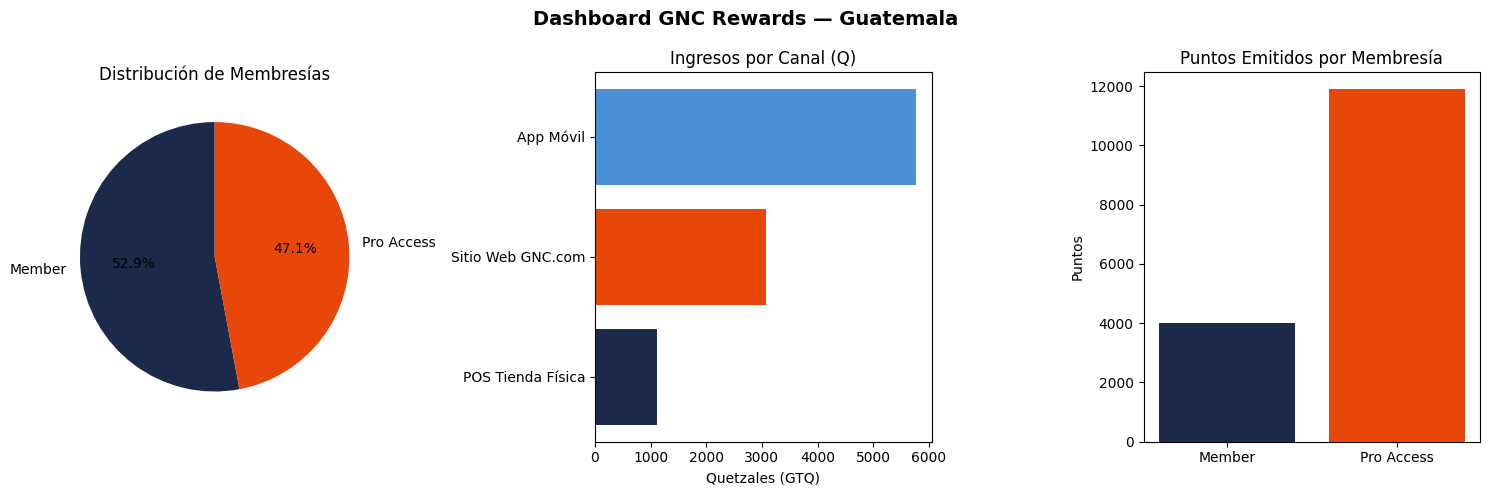

Dashboard generado


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# Crea una figura con 1 fila y 3 columnas de gráficos (subplots)
# figsize define el tamaño total de la figura (ancho=15, alto=5)


fig.suptitle('Dashboard GNC Rewards — Guatemala', fontsize=14, fontweight='bold')
# Agrega un título general para todo el dashboard
# fontsize define el tamaño de la letra
# fontweight='bold' lo pone en negrita


colores = ['#1B2A4A', '#E8470A', '#4A90D9', '#28A745', '#FFC107']
# Lista de colores en formato hexadecimal
# Se usarán para personalizar las gráficas


# Gráfica 1: Membresías
mem = df['membresia'].value_counts()# Cuenta cuántos clientes hay por cada tipo de membresía
axes[0].pie(mem.values, labels=mem.index, autopct='%1.1f%%',
            colors=['#1B2A4A', '#E8470A'], startangle=90)
# Crea una gráfica de pastel (pie chart)
# mem.values = cantidades
# mem.index = nombres de las categorías (Member, Pro Access)
# autopct muestra los porcentajes
# startangle rota el gráfico para mejor visualización


axes[0].set_title('Distribución de Membresías')# Título del primer gráfico

# Gráfica 2: Ingresos por fuente
por_fuente = df.groupby('fuente')['monto_gtq'].sum().sort_values(ascending=True)
# Agrupa los datos por "fuente" (App, Web, etc.)
# Suma los ingresos (monto_gtq) por cada fuente
# Ordena de menor a mayor


axes[1].barh(por_fuente.index, por_fuente.values, color=colores[:len(por_fuente)])
# Crea una gráfica de barras horizontales (barh)
# index = nombres de fuentes
# values = ingresos
# Se asignan colores de la lista

axes[1].set_title('Ingresos por Canal (Q)')# Título del segundo gráfico
axes[1].set_xlabel('Quetzales (GTQ)')# Etiqueta del eje X (dinero en quetzales)

# Gráfica 3: Puntos por membresía
puntos = df.groupby('membresia')['puntos_ganados'].sum()
# Agrupa por tipo de membresía
# Suma los puntos generados por cada tipo


axes[2].bar(puntos.index, puntos.values, color=['#1B2A4A', '#E8470A'])
# Crea una gráfica de barras verticales
# index = tipos de membresía
# values = total de puntos


axes[2].set_title('Puntos Emitidos por Membresía')# Título del tercer gráfico
axes[2].set_ylabel('Puntos')# Etiqueta del eje Y (cantidad de puntos)

plt.tight_layout()# Ajusta automáticamente los espacios entre gráficos para que no se encimen
plt.savefig('dashboard_gnc_guatemala.png', dpi=150, bbox_inches='tight')
# Guarda el dashboard como imagen PNG
# dpi=150 mejora la calidad
# bbox_inches='tight' elimina espacios innecesarios alrededor

plt.show()# Muestra el dashboard en pantalla
print("Dashboard generado")

**Reglas de negocio aplicadas:**
- Member: Q1 = 1 punto
- Pro Access: Q1 = 2 puntos  
- 100 puntos = Q1 de descuento

### 6. Referencias

1. GNC Holdings LLC. (2024). GNC Rewards Program Terms and Conditions. Recuperado de https://www.gnc.com/rewards


2. Wirth, R., & Hipp, J. (2000). CRISP-DM: Towards a standard process model for data mining. Proceedings of the 4th International Conference on Practical Applications of Knowledge Discovery and Data Mining.


3. Davenport, T. H., & Harris, J. G. (2007). Competing on Analytics: The New Science of Winning. Harvard Business Review Press.


4. McKinsey & Company. (2023). The value of getting personalization right in loyalty programs. McKinsey Insights